In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [4]:
movies = pd.read_csv('tmdb_movies.csv')

In [12]:
genres = pd.read_csv('tmdb_genres.csv')

# 1 Zwróć listę 10 najwyżej ocenianych filmów (vote_average), których liczba głosów (vote_count) jest większa od 3. kwartyla rozkładu liczby głosów.


In [5]:
q3 = movies['vote_count'].quantile(0.75)

top_movies = (
    movies[movies['vote_count'] > q3]
    .sort_values('vote_average', ascending=False)
    [['title', 'vote_average', 'vote_count']]
    .head(10)
)

print(top_movies)

                                title  vote_average  vote_count
1881         The Shawshank Redemption           8.5        8205
3337                    The Godfather           8.4        5893
2731           The Godfather: Part II           8.3        3338
3232                     Pulp Fiction           8.3        8428
3865                         Whiplash           8.3        4254
1818                 Schindler's List           8.3        4329
662                        Fight Club           8.3        9413
2294                    Spirited Away           8.3        3840
2170                           Psycho           8.2        2320
3719  One Flew Over the Cuckoo's Nest           8.2        2919


# 2 Pogrupuj tabelę w taki sposób, aby otrzymać średni przychód (revenue) oraz średni budżet (budget) w danym roku dla filmów opublikowanych od 2010 (włącznie) do 2016 roku (włącznie). Następnie na tej podstawie stwórz wykres, w którym średnie przychody są wykresem kolumnowym, a średni budżet wykresem liniowym na tych samych osiach. Sformatuj odpowiednio oś X oraz oś Y. Dodaj tytuł wykresu, oraz legendę, która znajduje się w prawym górnym rogu płótna, lecz poza obszarem osi. Przykład wykresu widoczny poniżej:

In [6]:
movies['release_date'] = pd.to_datetime(movies['release_date'])   # konwersja daty
movies['year'] = movies['release_date'].dt.year

In [7]:
movies_2010_2016 = movies[   #filtrowanie
    (movies['year'] >= 2010) &
    (movies['year'] <= 2016)
]

In [8]:
grouped = (                            #grupowanie
    movies_2010_2016
    .groupby('year')[['revenue', 'budget']]
    .mean()
)

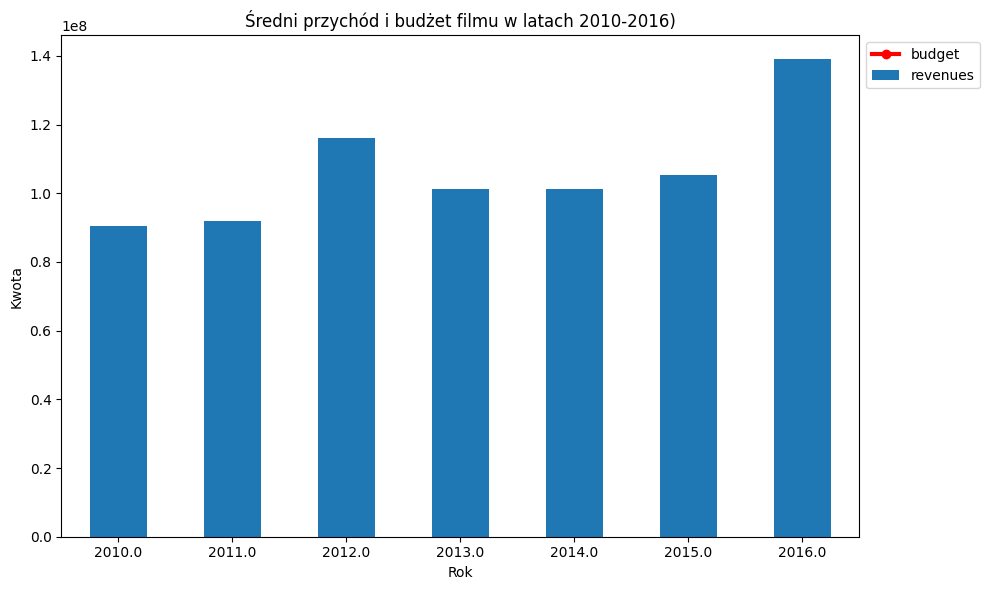

In [10]:
fig, ax = plt.subplots(figsize=(10,6))

# wykres kolumnowy revenue
grouped['revenue'].plot(
    kind='bar',
    ax=ax,
    label='revenues'
)

# druga oś dla budget
grouped['budget'].plot(
    kind='line',
    ax=ax,
    color='red',
    marker='o',
    linewidth=3,
    label='budget'
)

ax.set_title('Średni przychód i budżet filmu w latach 2010-2016)')
ax.set_xlabel('Rok')
ax.set_ylabel('Kwota')

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1,1)
)

plt.tight_layout()
plt.show()

# 3 Baza filmów zawiera kolumnę z id gatunku (genre_id). Na tej podstawie połącz ze sobą bazę filmów z bazą gatunków, tak aby w bazie filmów można było odczytać nazwę gatunku filmu.

In [13]:
import pandas as pd

movies = pd.read_csv('tmdb_movies.csv')
genres = pd.read_csv('tmdb_genres.csv')

In [15]:
genres

,Unnamed: 0,genres
0,28.0,Action
1,12.0,Adventure
2,14.0,Fantasy
3,16.0,Animation
4,878.0,Science Fiction
5,18.0,Drama
6,53.0,Thriller
7,10751.0,Family
8,35.0,Comedy
9,36.0,History


In [17]:
genres = genres.rename(columns={'Unnamed: 0': 'id'})

In [18]:
print(genres.head())

      id           genres
0   28.0           Action
1   12.0        Adventure
2   14.0          Fantasy
3   16.0        Animation
4  878.0  Science Fiction


In [19]:
movies_with_genres = movies.merge(
    genres,
    left_on='genre_id',
    right_on='id',
    how='left'
)

# 4 Jaki gatunek filmu z bazy pojawia się w niej najczęściej? Ile filmów tego gatunku znajduje się w bazie?


In [21]:
genre_count = movies_with_genres['genres'].value_counts()

most_common_genre = genre_count.idxmax()
count = genre_count.max()

print("Najczęstszy gatunek:", most_common_genre)
print("Liczba filmów:", count)

Najczęstszy gatunek: Drama
Liczba filmów: 1207


# 5 Filmy, którego gatunku trwają średnio najdłużej (runtime)?

In [22]:
runtime_mean = (movies_with_genres
                .groupby('genres')['runtime']
                .mean()
               )

In [23]:
longest_genre = runtime_mean.idxmax()
longest_runtime = runtime_mean.max()

print("Najdłuższy średni runtime:")
print(longest_genre)
print(longest_runtime)

Najdłuższy średni runtime:
History
133.96


# 6 Stwórz histogram czasu trwania filmów z gatunku, który cechuje się największym średnim czasem trwania.

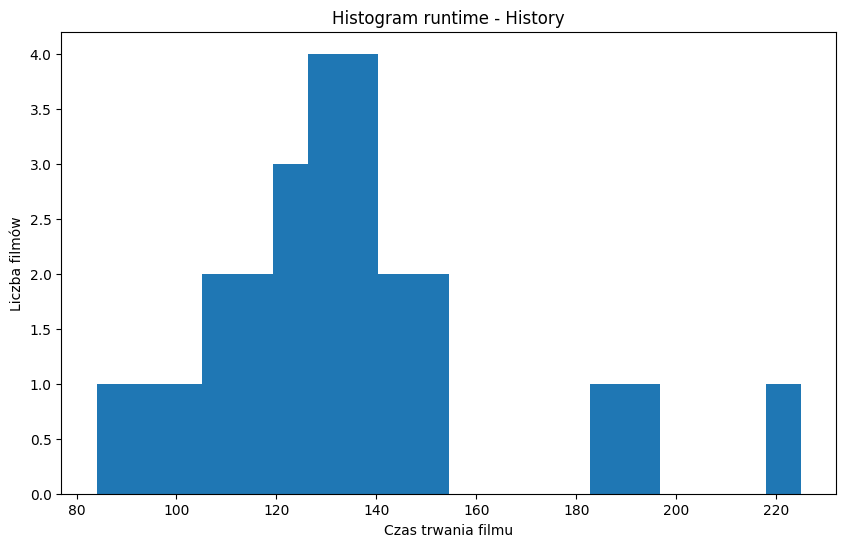

In [25]:
longest_movies = movies_with_genres[
    movies_with_genres['genres'] == longest_genre
]

plt.figure(figsize=(10,6))

plt.hist(longest_movies['runtime'], bins=20)

plt.title(f'Histogram runtime - {longest_genre}')
plt.xlabel('Czas trwania filmu')
plt.ylabel('Liczba filmów')

plt.show()